# Vehicle encoder — One-vs-Rest training

Same dataset and same backbone as `TrainCosineEncoder.ipynb`, but a different training signal:

- **Cosine version** — pairs `(a, b, label)` + `CosineEmbeddingLoss`. Learns directly that same-vehicle pairs should have cos→1, different-vehicle pairs cos→0.
- **OvR version** *(this notebook)* — every unique `vehicle_id` in the train set is a class. We attach an N-way `Linear(256, N)` head and train with `BCEWithLogitsLoss` (one binary classifier per vehicle, all trained jointly). The 256-D pre-head features become the embedding.

Backbone, image size, augmentations and eval protocol (cosine on held-out pairs → ROC-AUC) are identical, so the two approaches can be compared apples-to-apples.

## 1. Environment + dataset

dataset: https://drive.google.com/file/d/1NzTpWsB6HYPR7KzKt-pXb9xHL_nVCUNd/view?usp=share_link

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp /content/drive/MyDrive/vehicle_pairs_dataset.zip ./vehicle_pairs_dataset.zip
!mkdir -p ./dataset
!unzip -q ./vehicle_pairs_dataset.zip -d ./dataset

In [3]:
%pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948

## 2. Imports + config

In [4]:
import os, math, json, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

# Data layout (same as TrainCosineEncoder)
DATA_ROOT = Path('./dataset/pairs')
TRAIN_CSV = DATA_ROOT / 'pairs_train_clean.csv'
VAL_CSV   = DATA_ROOT / 'pairs_val_clean.csv'
TEST_CSV  = DATA_ROOT / 'pairs_test_clean.csv'

# Training hyper-params — kept aligned with the cosine notebook
IMG_SIZE     = 256
LATENT_DIM   = 256
BATCH_SIZE   = 128
NUM_WORKERS  = 2
EPOCHS       = 20
LR           = 1e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.0       # set to e.g. 0.05 if you want smoothing on the 1-labels

CKPT_DIR  = Path('./checkpoints'); CKPT_DIR.mkdir(exist_ok=True)
BEST_PATH = CKPT_DIR / 'encoder_ovr_best.pth'

print('Train:', TRAIN_CSV)
print('Val:  ', VAL_CSV)
print('Test: ', TEST_CSV)

device: cuda
Train: dataset/pairs/pairs_train_clean.csv
Val:   dataset/pairs/pairs_val_clean.csv
Test:  dataset/pairs/pairs_test_clean.csv


## 3. Build per-image dataset from pair CSVs

OvR needs `(image, vehicle_id)` rows, not pairs. Both columns of each pair contribute one row. We dedup by `path` to avoid the same image being seen twice per epoch.

**`vehicle_id → class_idx`** mapping is learned on the train set only. Val/test vehicles that don't appear in train get class `-1` (ignored — we never compute classification loss on them; they're used only for cosine-pair eval).

In [5]:
def unique_image_rows(pair_csv):
    df = pd.read_csv(pair_csv)
    a = df[['path_a','vehicle_id_a']].rename(columns={'path_a':'path','vehicle_id_a':'vehicle_id'})
    b = df[['path_b','vehicle_id_b']].rename(columns={'path_b':'path','vehicle_id_b':'vehicle_id'})
    return pd.concat([a, b], ignore_index=True).drop_duplicates(subset=['path']).reset_index(drop=True)

train_imgs = unique_image_rows(TRAIN_CSV)
print(f'train unique images: {len(train_imgs)}')

vehicle_ids = sorted(train_imgs['vehicle_id'].unique().tolist())
vid2cls = {v: i for i, v in enumerate(vehicle_ids)}
NUM_CLASSES = len(vid2cls)
print(f'unique vehicle_ids (= classes): {NUM_CLASSES}')

train_imgs['class_idx'] = train_imgs['vehicle_id'].map(vid2cls)

# Class-frequency stats
counts = train_imgs['class_idx'].value_counts()
print(f'images per vehicle  —  min={counts.min()}  median={int(counts.median())}  max={counts.max()}')

train unique images: 21511
unique vehicle_ids (= classes): 11450
images per vehicle  —  min=1  median=2  max=3


## 4. Letterbox + transforms (identical to cosine notebook)

In [6]:
class Letterbox:
    def __init__(self, size, fill=0):
        self.size = size; self.fill = fill
    def __call__(self, img):
        w, h = img.size
        scale = min(self.size/w, self.size/h)
        nw, nh = int(round(w*scale)), int(round(h*scale))
        img = img.resize((nw, nh), Image.BILINEAR)
        new_img = Image.new('RGB', (self.size, self.size), (self.fill,)*3)
        new_img.paste(img, ((self.size-nw)//2, (self.size-nh)//2))
        return new_img

train_tf = transforms.Compose([
    Letterbox(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
])
eval_tf = transforms.Compose([
    Letterbox(IMG_SIZE),
    transforms.ToTensor(),
])

## 5. Datasets / loaders

- **`SingleImageDataset`** for OvR training (one image + class_idx).
- **`PairsDataset`** kept around for val/test eval — identical to the cosine notebook.

In [7]:
class SingleImageDataset(Dataset):
    def __init__(self, df, root, transform):
        self.df = df.reset_index(drop=True)
        self.root = Path(root)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        for _ in range(5):
            row = self.df.iloc[idx]
            try:
                img = Image.open(self.root / row['path']).convert('RGB')
                return self.transform(img), int(row['class_idx'])
            except Exception:
                idx = (idx + 1) % len(self.df)
        raise RuntimeError('too many broken images in a row')

class PairsDataset(Dataset):
    def __init__(self, csv_path, root, transform):
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.root = Path(root); self.transform = transform
    def __len__(self): return len(self.df)
    def _load(self, rel):
        return self.transform(Image.open(self.root / rel).convert('RGB'))
    def __getitem__(self, idx):
        for _ in range(5):
            row = self.df.iloc[idx]
            try:
                return self._load(row['path_a']), self._load(row['path_b']), int(row['label'])
            except Exception:
                idx = (idx + 1) % len(self.df)
        raise RuntimeError('too many broken images in a row')

train_ds = SingleImageDataset(train_imgs, DATA_ROOT, train_tf)
val_ds   = PairsDataset(VAL_CSV,  DATA_ROOT, eval_tf)
test_ds  = PairsDataset(TEST_CSV, DATA_ROOT, eval_tf)

loader_kw = dict(num_workers=NUM_WORKERS, pin_memory=(DEVICE=='cuda'),
                 persistent_workers=(NUM_WORKERS > 0))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True, **loader_kw)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **loader_kw)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, **loader_kw)

print(f'Train rows: {len(train_ds)}  |  Val pairs: {len(val_ds)}  |  Test pairs: {len(test_ds)}')

Train rows: 21511  |  Val pairs: 1781  |  Test pairs: 1784


## 6. Backbone (identical mini-ResNet) + OvR head

In [8]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, stride, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, 1,       1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, stride, bias=False), nn.BatchNorm2d(out_ch))
        else:
            self.skip = nn.Identity()
    def forward(self, x):
        identity = self.skip(x)
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        return F.relu(out + identity, inplace=True)

def _stage(in_ch, out_ch, stride, n_blocks=2):
    layers = [ResBlock(in_ch, out_ch, stride)]
    for _ in range(n_blocks - 1):
        layers.append(ResBlock(out_ch, out_ch, 1))
    return nn.Sequential(*layers)

class OvREncoder(nn.Module):
    """
    Same backbone as the cosine encoder, plus a Linear(latent_dim, num_classes) head.

    `forward(x)`              -> logits over classes (training)
    `forward(x, embed=True)`  -> 256-D embedding before the head (inference)
    """
    def __init__(self, latent_dim=256, num_classes=1000):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, 2, 3, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, 2, 1),
        )
        self.stage1 = _stage(64,  64,  1)
        self.stage2 = _stage(64,  128, 2)
        self.stage3 = _stage(128, 256, 2)
        self.stage4 = _stage(256, 512, 2)
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.embed  = nn.Linear(512, latent_dim)
        self.head   = nn.Linear(latent_dim, num_classes)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='linear'); nn.init.zeros_(m.bias)

    def features(self, x):
        x = self.stem(x)
        x = self.stage1(x); x = self.stage2(x); x = self.stage3(x); x = self.stage4(x)
        x = self.pool(x).flatten(1)
        return self.embed(x)              # (B, latent_dim)

    def forward(self, x, embed=False):
        feat = self.features(x)
        if embed:
            return F.normalize(feat, dim=1)
        return self.head(feat)             # logits (B, num_classes)

model = OvREncoder(latent_dim=LATENT_DIM, num_classes=NUM_CLASSES).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'params: {n_params:.2f}M   classes: {NUM_CLASSES}')

params: 14.25M   classes: 11450


## 7. Loss / optimizer

`BCEWithLogitsLoss` over `NUM_CLASSES` outputs with **one-hot** targets = exactly the *One-vs-Rest* formulation (each of N output units is its own binary classifier trained jointly with the shared backbone).

Because each sample has only 1 positive out of N classes, every "rest" class contributes a tiny negative gradient. We balance with `pos_weight = N-1` so the average positive and negative gradient magnitudes match.

In [9]:
pos_weight = torch.full((NUM_CLASSES,), float(NUM_CLASSES - 1), device=DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

## 8. Train + eval loops

- **Train epoch** — classification BCE + top-1 accuracy.
- **Val/test epoch** — pair-level cosine, gap (pos_cos − neg_cos), ROC-AUC.

Eval doesn't touch the classification head — uses only the L2-normalised 256-D embedding.

In [10]:
def train_epoch(loader):
    model.train()
    tot_loss = tot_correct = tot_n = 0
    for x, y in tqdm(loader, desc='train', leave=False):
        x = x.to(DEVICE, non_blocking=True); y = y.to(DEVICE, non_blocking=True)
        target = torch.zeros(x.size(0), NUM_CLASSES, device=DEVICE)
        if LABEL_SMOOTH > 0:
            target.fill_(LABEL_SMOOTH / (NUM_CLASSES - 1))
            target.scatter_(1, y.unsqueeze(1), 1.0 - LABEL_SMOOTH)
        else:
            target.scatter_(1, y.unsqueeze(1), 1.0)

        logits = model(x)
        loss   = criterion(logits, target)

        optimizer.zero_grad(); loss.backward(); optimizer.step()

        bs = x.size(0)
        tot_loss    += loss.item() * bs
        tot_correct += (logits.argmax(1) == y).sum().item()
        tot_n       += bs
    return {'loss': tot_loss/tot_n, 'top1': tot_correct/tot_n}

@torch.no_grad()
def eval_pairs(loader):
    model.eval()
    all_cos, all_lab = [], []
    for a, b, lab in tqdm(loader, desc='eval', leave=False):
        a = a.to(DEVICE, non_blocking=True); b = b.to(DEVICE, non_blocking=True)
        ea = model(a, embed=True)
        eb = model(b, embed=True)
        cos = (ea * eb).sum(dim=1)             # already L2-normalised
        all_cos.append(cos.cpu().numpy())
        all_lab.append(lab.numpy())
    cos = np.concatenate(all_cos); lab = np.concatenate(all_lab)
    pos = cos[lab == 1].mean() if (lab == 1).any() else float('nan')
    neg = cos[lab == 0].mean() if (lab == 0).any() else float('nan')
    auc = roc_auc_score(lab, cos) if len(np.unique(lab)) > 1 else float('nan')
    return {'pos_cos': pos, 'neg_cos': neg, 'gap': pos - neg, 'auc': auc}

## 9. Train

In [11]:
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'
import mlflow
mlflow.set_tracking_uri('file:./mlruns')
mlflow.set_experiment('vehicle-ovr-encoder')

history = []
best_auc = -float('inf')

with mlflow.start_run(run_name='ovr_mini_resnet'):
    mlflow.log_params({
        'img_size': IMG_SIZE, 'latent_dim': LATENT_DIM, 'batch_size': BATCH_SIZE,
        'epochs': EPOCHS, 'lr': LR, 'weight_decay': WEIGHT_DECAY,
        'num_classes': NUM_CLASSES, 'optimizer': 'AdamW',
        'scheduler': 'CosineAnnealingLR', 'loss': 'BCEWithLogitsLoss(pos_weight=N-1)',
        'backbone': 'mini_resnet_4stage_512', 'n_params_M': round(n_params, 2),
    })

    for epoch in range(1, EPOCHS + 1):
        tr = train_epoch(train_loader)
        va = eval_pairs(val_loader)
        scheduler.step()

        row = {'epoch': epoch, **{f'train_{k}': v for k,v in tr.items()},
               **{f'val_{k}': v for k,v in va.items()}}
        history.append(row)

        print(f"epoch {epoch:02d}  "
              f"train_loss={tr['loss']:.4f}  train_top1={tr['top1']*100:.1f}%  "
              f"val_auc={va['auc']:.4f}  pos={va['pos_cos']:.3f}  neg={va['neg_cos']:.3f}  gap={va['gap']:.3f}")

        mlflow.log_metrics({
            'train_loss': tr['loss'], 'train_top1': tr['top1'],
            'val_auc':    va['auc'],  'val_pos_cos': va['pos_cos'],
            'val_neg_cos': va['neg_cos'], 'val_gap': va['gap'],
        }, step=epoch)

        if va['auc'] > best_auc:
            best_auc = va['auc']
            torch.save({
                'state_dict': model.state_dict(),
                'vid2cls':    vid2cls,
                'config':     {'latent_dim': LATENT_DIM, 'num_classes': NUM_CLASSES, 'img_size': IMG_SIZE},
                'epoch':      epoch,
                'val_auc':    va['auc'],
            }, BEST_PATH)
            mlflow.log_metric('best_val_auc', best_auc, step=epoch)
            print(f'  ✓ new best — saved to {BEST_PATH}')

    mlflow.log_artifact(str(BEST_PATH))
    pd.DataFrame(history).to_csv('history_ovr.csv', index=False)
    mlflow.log_artifact('history_ovr.csv')

2026/06/24 19:14:22 INFO mlflow.tracking.fluent: Experiment with name 'vehicle-ovr-encoder' does not exist. Creating a new experiment.


train:   0%|          | 0/168 [00:00<?, ?it/s]

eval:   0%|          | 0/14 [00:00<?, ?it/s]

epoch 01  train_loss=1.4402  train_top1=0.0%  val_auc=0.6563  pos=0.961  neg=0.937  gap=0.024
  ✓ new best — saved to checkpoints/encoder_ovr_best.pth


train:   0%|          | 0/168 [00:00<?, ?it/s]

...

eval:   0%|          | 0/14 [00:00<?, ?it/s]

epoch 19  train_loss=0.0882  train_top1=0.9%  val_auc=0.8926  pos=0.705  neg=0.302  gap=0.403
  ✓ new best — saved to checkpoints/encoder_ovr_best.pth


train:   0%|          | 0/168 [00:00<?, ?it/s]

eval:   0%|          | 0/14 [00:00<?, ?it/s]

epoch 20  train_loss=0.0869  train_top1=0.8%  val_auc=0.8923  pos=0.706  neg=0.305  gap=0.400


## 10. Final eval on test

In [15]:
# Reload best checkpoint
ckpt = torch.load(BEST_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['state_dict'])
model.eval()
print(f"best epoch={ckpt['epoch']}  val_auc={ckpt['val_auc']:.4f}")

te = eval_pairs(test_loader)
print('TEST  ', {k: round(v, 4) for k, v in te.items()})

best epoch=19  val_auc=0.8926


eval:   0%|          | 0/14 [00:00<?, ?it/s]

TEST   {'pos_cos': np.float32(0.7039), 'neg_cos': np.float32(0.3196), 'gap': np.float32(0.3843), 'auc': np.float64(0.8824)}


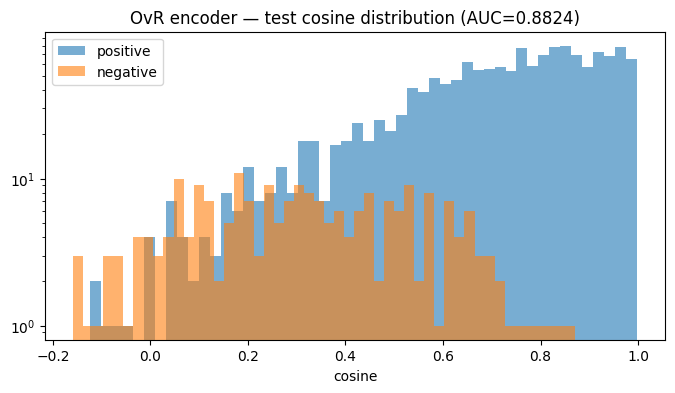

In [16]:
import matplotlib.pyplot as plt

# Collect raw cosines on the test set for histogram
all_cos, all_lab = [], []
with torch.no_grad():
    for a, b, lab in test_loader:
        a = a.to(DEVICE); b = b.to(DEVICE)
        c = (model(a, embed=True) * model(b, embed=True)).sum(dim=1)
        all_cos.append(c.cpu().numpy()); all_lab.append(lab.numpy())
cos = np.concatenate(all_cos); lab = np.concatenate(all_lab)

plt.figure(figsize=(8,4))
plt.hist(cos[lab==1], bins=50, alpha=0.6, label='positive')
plt.hist(cos[lab==0], bins=50, alpha=0.6, label='negative')
plt.yscale('log'); plt.xlabel('cosine'); plt.legend()
plt.title(f'OvR encoder — test cosine distribution (AUC={te["auc"]:.4f})')
plt.show()

## 11. Export — drop-in HF format compatible with `img2vec_example.py`

We save only the **backbone + embed** layers (no classification head) under the same `VehicleEncoderModel` interface used by the cosine encoder. After upload, `AutoModel.from_pretrained('YOUR_REPO', trust_remote_code=True)` returns a model whose `forward(x)` produces the L2-normalised 256-D embedding.

In [ ]:
stripped = {k: v for k, v in model.state_dict().items() if not k.startswith('head.')}
torch.save(stripped, CKPT_DIR / 'encoder_ovr_stripped.pth')
print('saved backbone-only weights:', CKPT_DIR / 'encoder_ovr_stripped.pth')


In [17]:
from sklearn.metrics import roc_auc_score, roc_curve

# 1) Build path -> embedding lookup over all unique images referenced by TEST_CSV
test_pairs_df = pd.read_csv(TEST_CSV)
unique_paths  = pd.unique(pd.concat([test_pairs_df['path_a'], test_pairs_df['path_b']], ignore_index=True))
print(f'unique test images: {len(unique_paths)}')

class _SinglePathDataset(Dataset):
    def __init__(self, paths, root, transform):
        self.paths = list(paths); self.root = Path(root); self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        p = self.paths[i]
        return self.transform(Image.open(self.root / p).convert('RGB')), i

enc_ds = _SinglePathDataset(unique_paths, DATA_ROOT, eval_tf)
enc_loader = DataLoader(enc_ds, batch_size=BATCH_SIZE, shuffle=False, **loader_kw)

embeddings = np.zeros((len(unique_paths), LATENT_DIM), dtype=np.float32)
model.eval()
with torch.no_grad():
    for x, idxs in tqdm(enc_loader, desc='encoding test images'):
        x = x.to(DEVICE, non_blocking=True)
        e = model(x, embed=True).cpu().numpy().astype(np.float32)
        embeddings[idxs.numpy()] = e

lookup = {str(p): i for i, p in enumerate(unique_paths)}

# 2) Iterate the test pairs CSV exactly like analyze_dataset.py
pairs   = test_pairs_df
sims, labels = [], []
missing = 0
for _, p in pairs.iterrows():
    ia = lookup.get(str(p['path_a']))
    ib = lookup.get(str(p['path_b']))
    if ia is None or ib is None:
        missing += 1
        continue
    va, vb = embeddings[ia], embeddings[ib]
    sims.append(float(va @ vb))
    labels.append(int(p['label']))

sims = np.asarray(sims); labels = np.asarray(labels)
print(f'pairs evaluated: {len(sims)}   missing (no embedding): {missing}')
print(f'positives: {(labels==1).sum()}   negatives: {(labels==0).sum()}')
print(f'ROC-AUC: {roc_auc_score(labels, sims):.4f}')
print(f'mean cos pos: {sims[labels==1].mean():.4f}   mean cos neg: {sims[labels==0].mean():.4f}')

# Best threshold via Youden's J
fpr, tpr, thr = roc_curve(labels, sims)
j = tpr - fpr
best = int(np.argmax(j))
print(f'best threshold = {thr[best]:.4f}   (TPR={tpr[best]:.3f}, FPR={fpr[best]:.3f})')

unique test images: 3534


encoding test images:   0%|          | 0/28 [00:00<?, ?it/s]

pairs evaluated: 1784   missing (no embedding): 0
positives: 1558   negatives: 226
ROC-AUC: 0.8824
mean cos pos: 0.7039   mean cos neg: 0.3196
best threshold = 0.5392   (TPR=0.807, FPR=0.190)
